In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [4]:
df = pd.read_excel("Cleaned data.xlsx")
df.head()

,Group column,Order ID,Order Date,Customer,City,Pincode,Product,Category,Quantity,Unit Price,Discount,GST,Net Amount,Payment Mode,Delivery Status
0,0,BLK1025495,2026-06-26,Aditya Malhotra,Noida,201301,Britannia Bread 400g,Bakery,2,48,6,4.32,94.32,UPI,Delivered
1,1,BLK1025496,2026-06-26,Nidhi Arora,Delhi,110034,Lay's Magic Masala 52g,Snacks,5,20,10,8.10,98.10,Wallet,Delivered
2,2,BLK1025497,2026-06-26,Karan Gupta,Ghaziabad,201001,Surf Excel Easy Wash 1kg,Household,1,235,20,38.70,253.70,COD,Delivered
3,3,BLK1025498,2026-06-26,Pooja Verma,Gurgaon,122002,Dettol Hand Wash 900ml,Personal Care,2,185,25,62.10,407.10,UPI,Delivered
4,4,BLK1025499,2026-06-26,Saurabh Jain,Faridabad,121003,Haldiram Bhujia 400g,Snacks,3,145,18,37.53,454.53,Credit Card,Cancelled


In [5]:
df.describe()


,Group column,Order Date,Pincode,Quantity,Unit Price,Discount,GST,Net Amount
count,210.000000,210,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,104.500000,2026-06-29 18:37:42.857142,149983.985714,2.119048,220.338095,20.809524,20.773238,363.001810
min,0.000000,2026-06-26 00:00:00,110015.000000,1.000000,20.000000,4.000000,3.420000,83.420000
25%,52.250000,2026-06-30 00:00:00,110085.000000,1.000000,125.000000,15.000000,14.150000,278.250000
50%,104.500000,2026-06-30 00:00:00,122011.000000,2.000000,185.000000,20.000000,18.000000,351.750000
75%,156.750000,2026-06-30 00:00:00,201014.000000,2.000000,285.000000,25.000000,23.662500,430.700000
max,209.000000,2026-06-30 00:00:00,201309.000000,6.000000,945.000000,75.000000,81.900000,913.500000
std,60.765944,NaN,42131.196836,1.049091,150.782441,10.259872,12.754774,143.143151


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Group column     210 non-null    int64         
 1   Order ID         210 non-null    str           
 2   Order Date       210 non-null    datetime64[us]
 3   Customer         210 non-null    str           
 4   City             210 non-null    str           
 5   Pincode          210 non-null    int64         
 6   Product          210 non-null    str           
 7   Category         210 non-null    str           
 8   Quantity         210 non-null    int64         
 9   Unit Price       210 non-null    int64         
 10  Discount         210 non-null    int64         
 11  GST              210 non-null    float64       
 12  Net Amount       210 non-null    float64       
 13  Payment Mode     210 non-null    str           
 14  Delivery Status  210 non-null    str           
dtype

In [7]:
df.head()


,Group column,Order ID,Order Date,Customer,City,Pincode,Product,Category,Quantity,Unit Price,Discount,GST,Net Amount,Payment Mode,Delivery Status
0,0,BLK1025495,2026-06-26,Aditya Malhotra,Noida,201301,Britannia Bread 400g,Bakery,2,48,6,4.32,94.32,UPI,Delivered
1,1,BLK1025496,2026-06-26,Nidhi Arora,Delhi,110034,Lay's Magic Masala 52g,Snacks,5,20,10,8.10,98.10,Wallet,Delivered
2,2,BLK1025497,2026-06-26,Karan Gupta,Ghaziabad,201001,Surf Excel Easy Wash 1kg,Household,1,235,20,38.70,253.70,COD,Delivered
3,3,BLK1025498,2026-06-26,Pooja Verma,Gurgaon,122002,Dettol Hand Wash 900ml,Personal Care,2,185,25,62.10,407.10,UPI,Delivered
4,4,BLK1025499,2026-06-26,Saurabh Jain,Faridabad,121003,Haldiram Bhujia 400g,Snacks,3,145,18,37.53,454.53,Credit Card,Cancelled


### Dates and months present

In [8]:
df['Order Date'].dt.month_name().unique()

<StringArray>
['June']
Length: 1, dtype: str

In [9]:
df['Order Date'].unique()

<DatetimeArray>
['2026-06-26 00:00:00', '2026-06-27 00:00:00', '2026-06-28 00:00:00',
 '2026-06-29 00:00:00', '2026-06-30 00:00:00']
Length: 5, dtype: datetime64[us]

### Top 5 winning and losing product

In [10]:
print("Winners")
print("Sum of revenue")
print(df.groupby('Product')['Net Amount'].sum().sort_values(ascending=False).head())
print("Average of revenue")
print(df.groupby('Product')['Net Amount'].mean().sort_values(ascending=False).head())
print("no. of times brought")
df['Product'].value_counts().head()


Winners
Sum of revenue
Product
Cadbury Dairy Milk Silk 150g    1293.50
Pringles Original 107g          1240.25
Saffola Gold Oil 5L              913.50
Saffola Active Oil 5L            892.50
Tata Sampann Moong Dal 1kg       852.60
Name: Net Amount, dtype: float64
Average of revenue
Product
Saffola Gold Oil 5L                   913.50
Saffola Active Oil 5L                 892.50
Kellogg's Chocos Moon & Stars 700g    771.75
Kellogg's Chocos 650g                 750.25
Nivea Body Lotion 400ml               727.85
Name: Net Amount, dtype: float64
no. of times brought


Product
Pringles Original 107g          3
Amul Butter 500g                2
Coca Cola 750ml                 2
Colgate Strong Teeth 200g       2
Cadbury Dairy Milk Silk 150g    2
Name: count, dtype: int64

In [11]:
print("Losers")
print("Sum of revenue")
print(df.groupby('Product')['Net Amount'].sum().sort_values(ascending=True).head())
print("Average of revenue")
print(df.groupby('Product')['Net Amount'].mean().sort_values(ascending=True).head())
print("no. of times brought")
df['Product'].value_counts().head()

Losers
Sum of revenue
Product
Tata Salt Lite 1kg                    83.42
Lay's American Style Cream & Onion    87.20
Britannia Bread 400g                  94.32
Tata Salt 1kg                         96.22
Lay's Magic Masala 52g                98.10
Name: Net Amount, dtype: float64
Average of revenue
Product
Tata Salt Lite 1kg                    83.42
Lay's American Style Cream & Onion    87.20
Britannia Bread 400g                  94.32
Tata Salt 1kg                         96.22
Lay's Magic Masala 52g                98.10
Name: Net Amount, dtype: float64
no. of times brought


Product
Pringles Original 107g          3
Amul Butter 500g                2
Coca Cola 750ml                 2
Colgate Strong Teeth 200g       2
Cadbury Dairy Milk Silk 150g    2
Name: count, dtype: int64

### Top 5 cities in terms of revenue

In [12]:
print("Sum of revenue")
print(df.groupby('City')['Net Amount'].sum().sort_values(ascending=False))
print("Average of revenue")
print(df.groupby('City')['Net Amount'].mean().sort_values(ascending=False))
print("no. of times brought")
df['City'].value_counts()

Sum of revenue
City
Delhi        23509.16
Gurgaon      16052.63
Noida        15553.80
Ghaziabad    14147.16
Faridabad     6967.63
Name: Net Amount, dtype: float64
Average of revenue
City
Gurgaon      382.205476
Delhi        373.161270
Ghaziabad    353.679000
Noida        353.495455
Faridabad    331.791905
Name: Net Amount, dtype: float64
no. of times brought


City
Delhi        63
Noida        44
Gurgaon      42
Ghaziabad    40
Faridabad    21
Name: count, dtype: int64

### Delivery status 

In [13]:
df['Delivery Status'].unique()

<StringArray>
[' Delivered', ' Cancelled']
Length: 2, dtype: str

In [14]:
print("Sum of revenue")
print(df.groupby('Delivery Status')['Net Amount'].sum().sort_values(ascending=False))
print("Average of revenue")
print(df.groupby('Delivery Status')['Net Amount'].mean().sort_values(ascending=False))
print("no. of times brought")
df['Delivery Status'].value_counts()


Sum of revenue
Delivery Status
Delivered    71960.26
Cancelled     4270.12
Name: Net Amount, dtype: float64
Average of revenue
Delivery Status
Cancelled    427.0120
Delivered    359.8013
Name: Net Amount, dtype: float64
no. of times brought


Delivery Status
Delivered    200
Cancelled     10
Name: count, dtype: int64

### Top 5 categories generating high revenue

In [15]:

print("Sum of revenue")
print(df.groupby('Category')['Net Amount'].sum().sort_values(ascending=False).head())
print("Average of revenue")
print(df.groupby('Category')['Net Amount'].mean().sort_values(ascending=False).head())
print("no. of times brought")
df['Category'].value_counts().head()

Sum of revenue
Category
Grocery          16542.11
Personal Care    13968.24
Snacks           10121.54
Beverages         8848.45
Household         7915.42
Name: Net Amount, dtype: float64
Average of revenue
Category
Chocolates       496.666667
Breakfast        489.775000
Health Drinks    481.400000
Grocery          413.552750
Personal Care    399.092571
Name: Net Amount, dtype: float64
no. of times brought


Category
Grocery          40
Snacks           36
Personal Care    35
Beverages        30
Household        21
Name: count, dtype: int64

### Payment mode and revenue

In [16]:
print("Sum of revenue")
print(df.groupby('Payment Mode')['Net Amount'].sum().sort_values(ascending=False))
print("Average of revenue")
print(df.groupby('Payment Mode')['Net Amount'].mean().sort_values(ascending=False))
print("no. of times brought")
df['Payment Mode'].value_counts()


Sum of revenue
Payment Mode
UPI            28082.06
COD            17506.23
Credit Card    17109.05
Wallet         13533.04
Name: Net Amount, dtype: float64
Average of revenue
Payment Mode
Credit Card    397.884884
COD            372.472979
UPI            360.026410
Wallet         322.215238
Name: Net Amount, dtype: float64
no. of times brought


Payment Mode
UPI            78
COD            47
Credit Card    43
Wallet         42
Name: count, dtype: int64

In [18]:
df['Discount']=df['Discount']/100

### Correlations


In [19]:
df.corr(numeric_only=True)

,Group column,Pincode,Quantity,Unit Price,Discount,GST,Net Amount
Group column,1.000000,-0.006442,0.008143,0.033307,0.003361,-0.074120,-0.019541
Pincode,-0.006442,1.000000,-0.301637,0.095306,-0.045305,0.103396,-0.055245
Quantity,0.008143,-0.301637,1.000000,-0.659772,-0.397513,-0.225419,-0.240560
Unit Price,0.033307,0.095306,-0.659772,1.000000,0.914318,0.488258,0.703661
Discount,0.003361,-0.045305,-0.397513,0.914318,1.000000,0.548493,0.783142
GST,-0.074120,0.103396,-0.225419,0.488258,0.548493,1.000000,0.589690
Net Amount,-0.019541,-0.055245,-0.240560,0.703661,0.783142,0.589690,1.000000


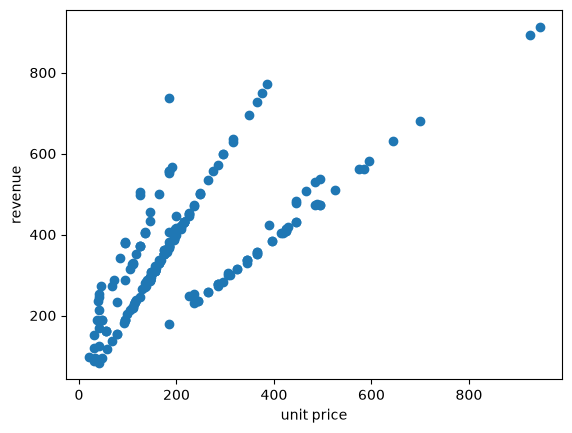

In [27]:
import matplotlib.pylab as plt
plt.scatter(df['Unit Price'],df['Net Amount'])
plt.xlabel("unit price")
plt.ylabel("revenue")
plt.show()


In [ ]:
from sklearn.metrics import r2_score


### Revenue using unit price (Prediction model)

In [21]:
X=df[['Unit Price']]
y=df['Net Amount']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=22
)

In [ ]:
#Using Linera Regression

model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
print("Mse:",mse)
rmse = np.sqrt(mse)
print("Rmse:",rmse)
r2=r2_score(y_test,y_pred)
print("R2",r2)

Mse: 8788.960341447515
Rmse: 93.7494551528035
R2 0.3888153178408348


In [ ]:
#using Decision tree regressor

model2=DecisionTreeRegressor(random_state=44)
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
mse2=mean_squared_error(y_test,y_pred2)
print("Mse:",mse2)
rmse2 = np.sqrt(mse2)
print("Rmse:",rmse2)
r2=r2_score(y_test,y_pred2)
print("R2",r2)

Mse: 11072.992140145501
Rmse: 105.22828583677253
R2 0.22998364780297187


In [ ]:
#Using Random Forest Regressor

model3=RandomForestRegressor(random_state=44)
model3.fit(X_train,y_train)
y_pred3=model3.predict(X_test)
mse3=mean_squared_error(y_test,y_pred3)
print("Mse:",mse3)
rmse3 = np.sqrt(mse3)
print("Rmse:",rmse3)
r2=r2_score(y_test,y_pred3)
print("R2",r2)

Mse: 11250.16853966396
Rmse: 106.06681167860171
R2 0.21766279331974858


In [ ]:
#Using Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
model.fit(X_train_poly,y_train)
y_pred4=model.predict(X_test_poly)
mse4=mean_squared_error(y_test,y_pred4)
rmse4=np.sqrt(mse)
print("Mse:",mse4)
print("Rmse:",rmse4)
r2=r2_score(y_test,y_pred4)
print("R2",r2)

Mse: 8600.563745505844
Rmse: 93.7494551528035
R2 0.4019164252684643


### Revenue using discount (Prediction model)

### Unit price using Revenue (Prediction model)

### Discount using Revenue (Prediction model)

### Discount using Unit price (Prediction model)